[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/CienciasPlanetarias/blob/main/Problemsets/Problemset2/Problema1y2.ipynb)

---
# Problemset 2 — Solución computacional

**Problema 1:** Perfiles de estructura interna de un planeta tipo Tierra (4 capas)  
**Problema 2:** Tamaño de las magnetosferas de los planetas gigantes del Sistema Solar


# Problema 1 — Estructura interna de un planeta tipo Tierra

Para calcular los perfiles de densidad, masa, gravedad, presión y temperatura de un planeta tipo terrestre, el estudio de **Valencia et al. (2006)** propone resolver un sistema de ecuaciones diferenciales ordinarias acopladas con una ecuación de estado (EOS) y un modelo de transporte de calor.

### 1. Sistema de ecuaciones fundamentales
En un planeta con simetría esférica, el estado físico en función del radio $r$ se describe con cuatro ecuaciones:

1. **Densidad** — ecuación de **Adams-Williamson**:
   $$\frac{d\rho}{dr} = \frac{-\rho(r)\,g(r)}{\phi(r)}, \qquad \phi = K_S/\rho \text{ (parámetro sísmico)}$$

2. **Masa acumulada:**
   $$\frac{dm}{dr} = 4\pi r^2\rho(r)$$

3. **Presión** — equilibrio hidrostático:
   $$\frac{dP}{dr} = -\rho(r)\,g(r)$$

4. **Temperatura** — gradiente adiabático (núcleo y manto):
   $$\frac{dT}{dr} = -\frac{\gamma(r)\,g(r)\,T(r)}{\phi(r)}$$
   En la corteza se aplica un gradiente geotérmico conductivo lineal ($\approx 20$ K/km).

### 2. Modelo de densidad PREM
Se usan los polinomios del **Modelo de Referencia de la Tierra Preliminar (PREM)** de Dziewonski & Anderson (1981), con $x = r/R_\oplus$:


| Capa | Rango del Radio ($r$ en km) | Expresión de la Densidad $\rho(x)$ [kg/m³] |
| :--- | :--- | :--- |
| **Núcleo Interno (Sólido)** | $0 \le r \le 1221.5$ | $10^3 (13.0885 - 8.8381x^2)$ |
| **Núcleo Externo (Líquido)** | $1221.5 < r \le 3480$ | $10^3 (12.5815 - 1.2638x - 3.6426x^2 - 5.5281x^3)$ |
| **Manto Inferior** | $3480 < r \le 5701$ | $10^3 (7.9565 - 6.4761x + 5.5283x^2 - 3.0807x^3)$ |
| **Zona de Transición (1)** | $5701 < r \le 5771$ | $10^3 (5.3197 - 1.4836x)$ |
| **Zona de Transición (2)** | $5771 < r \le 5971$ | $10^3 (11.2494 - 8.0298x)$ |
| **Zona de Transición (3)** | $5971 < r \le 6151$ | $10^3 (7.1089 - 3.8045x)$ |
| **Manto Superior (LID/LVZ)** | $6151 < r \le 6346.6$ | $10^3 (2.6910 + 0.6924x)$ |
| **Corteza Inferior** | $6346.6 < r \le 6356$ | $2900$ (constante) |
| **Corteza Superior** | $6356 < r \le 6368$ | $2600$ (constante) |
| **Capa Oceánica** | $6368 < r \le 6371$ | $1020$ (constante) |

### Notas sobre la corrección:
*   **Segmentación del Manto:** La expresión que tenías para el manto solo es válida hasta los **5701 km**. Por encima de esa profundidad, PREM divide el interior en tres capas de transición y el manto superior (zonas LVZ y LID) con funciones distintas debido a los cambios de fase mineralógica.
*   **Límite de la Corteza (Moho):** El modelo PREM sitúa la base de la corteza a un radio de **6346.6 km** (una profundidad de 24.4 km), no a 6336 km.
*   **Estructura de la Corteza:** La corteza no tiene una densidad única de 2750 kg/m³; se divide en una capa inferior de **2900 kg/m³** y una superior de **2600 kg/m³**.




### 3. Algoritmo de implementación
1. Construir $\rho(r)$ con los polinomios PREM.
2. Integrar $m(r) = \int_0^r 4\pi r'^2\rho(r')\,dr'$ por cuadratura trapezoidal.
3. Calcular $g(r) = Gm(r)/r^2$.
4. Integrar la presión desde la superficie: $P(r) = \int_r^R \rho g\,dr'$.
5. Integrar el perfil de temperatura con $T_\text{CMB} = 3700$ K como condición de contorno.


In [ ]:
import numpy as np
from scipy.integrate import cumulative_trapezoid, solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── Constantes físicas ─────────────────────────────────────────────
G   = 6.674e-11    # constante gravitacional  [m³ kg⁻¹ s⁻²]
kB  = 1.381e-23    # constante de Boltzmann   [J/K]
m_p = 1.673e-27    # masa del protón           [kg]
mu0 = 4*np.pi*1e-7 # permeabilidad del vacío  [H/m]

# ── Parámetros de la Tierra ────────────────────────────────────────
R_E  = 6.371e6    # radio superficial [m]
M_E  = 5.972e24   # masa total        [kg]

# ── Fronteras de las cuatro capas (radio desde el centro) ─────────
r_IC   = 1.221e6  # Inner Core Boundary    (ICB)  [m]
r_CMB  = 3.480e6  # Core–Mantle Boundary   (CMB)  [m]
r_Moho = 6.336e6  # Discontinuidad de Mohorovičić [m]

# ── Sistema Solar ──────────────────────────────────────────────────
AU    = 1.496e11   # unidad astronómica [m]
M_sun = 1.989e30   # masa solar         [kg]
R_sun = 6.957e8    # radio solar         [m]

print("Librerías importadas y constantes definidas ✓")


Librerías importadas y constantes definidas ✓


## 1.1 Perfil de densidad, masa, gravedad y presión

Se construye el perfil de densidad PREM y se integran numericamente la masa acumulada, la aceleración gravitacional y la presión hidrostática.


In [ ]:
# ── Perfil de densidad PREM (Dziewonski & Anderson 1981) ─────────
def rho_PREM(r):
    """Densidad [kg/m³] en función del radio r [m], basada en PREM."""
    x = r / R_E
    if r <= r_IC:
        return 1e3 * (13.0885 - 8.8381*x**2)
    elif r <= r_CMB:
        return 1e3 * (12.5815 - 1.2638*x - 3.6426*x**2 - 5.5281*x**3)
    elif r <= r_Moho:
        return 1e3 * (7.9565  - 6.4761*x + 5.5283*x**2 - 3.0807*x**3)
    else:
        return 2750.0   # corteza promedio [kg/m³]

rho_v = np.vectorize(rho_PREM)

# ── Grid radial (más puntos cerca de las discontinuidades) ────────
r = np.concatenate([
    np.linspace(0,          r_IC,   1200),   # núcleo sólido
    np.linspace(r_IC   + 1, r_CMB,  2000),   # núcleo líquido
    np.linspace(r_CMB  + 1, r_Moho, 2500),   # manto
    np.linspace(r_Moho + 1, R_E,     500),   # corteza
])
rho = rho_v(r)   # densidad en cada punto [kg/m³]

# ── Masa acumulada: m(r) = ∫₀ʳ 4π r'² ρ(r') dr' ─────────────────
m = np.zeros_like(r)
m[1:] = cumulative_trapezoid(4*np.pi * r**2 * rho, r)

# ── Aceleración gravitacional: g(r) = G m(r) / r² ────────────────
g = np.zeros_like(r)
g[1:] = G * m[1:] / r[1:]**2

# ── Presión hidrostática: P(r) = ∫ᵣᴿ ρ g dr' con P(R_E) = 0 ─────
P = np.zeros_like(r)
for i in range(len(r) - 2, -1, -1):
    P[i] = P[i+1] + 0.5*(rho[i]+rho[i+1]) * 0.5*(g[i]+g[i+1]) * (r[i+1]-r[i])

# ── Índices de las fronteras ──────────────────────────────────────
i_IC   = np.argmin(np.abs(r - r_IC))
i_CMB  = np.argmin(np.abs(r - r_CMB))
i_Moho = np.argmin(np.abs(r - r_Moho))

print("Verificación con PREM (Dziewonski & Anderson 1981):")
print(f"  Centro     :  ρ = {rho[0]:.0f} kg/m³   P = {P[0]/1e9:.0f} GPa    (ref: ~364 GPa)")
print(f"  ICB  (1221 km): salto ρ = {rho[i_IC]:.0f}→{rho[i_IC+1]:.0f} kg/m³   P = {P[i_IC]/1e9:.0f} GPa   (ref: ~328 GPa)")
print(f"  CMB  (3480 km): salto ρ = {rho[i_CMB]:.0f}→{rho[i_CMB+1]:.0f} kg/m³  P = {P[i_CMB]/1e9:.0f} GPa   (ref: ~136 GPa)")
print(f"  Moho (6336 km): P = {P[i_Moho]/1e9:.2f} GPa   g = {g[i_Moho]:.2f} m/s²  (ref: 9.82 m/s²)")
print(f"  g_máx: {g.max():.2f} m/s² en r = {r[g.argmax()]/1e6:.3f} Mm   (ref: ~10.7 m/s² en CMB)")
print(f"  Masa total: {m[-1]/M_E:.4f} M_E")


Verificación con PREM (Dziewonski & Anderson 1981):
  Centro     :  ρ = 13088 kg/m³   P = 368 GPa    (ref: ~364 GPa)
  ICB  (1221 km): salto ρ = 12764→12167 kg/m³   P = 333 GPa   (ref: ~328 GPa)
  CMB  (3480 km): salto ρ = 9903→5566 kg/m³  P = 140 GPa   (ref: ~136 GPa)
  Moho (6336 km): P = 0.97 GPa   g = 10.12 m/s²  (ref: 9.82 m/s²)
  g_máx: 10.69 m/s² en r = 3.480 Mm   (ref: ~10.7 m/s² en CMB)
  Masa total: 1.0271 M_E


\
## 1.2 Perfil de temperatura

El gradiente adiabático es válido en el manto convectivo y en los núcleos:

$$\frac{dT}{dr} = -\frac{\gamma(r)\,g(r)\,T(r)}{\phi(r)}$$

Se integra esta ODE desde el CMB ($T_\text{CMB} = 3700$ K) hacia el interior (núcleos) y hacia el exterior (manto). En la corteza se aplica un gradiente geotérmico conductivo lineal. Los parámetros $\phi$ y $\gamma$ por capa proceden de Valencia et al. (2006) y datos sísmicos (PREM).


In [ ]:
# ── Parámetros termales por capa ──────────────────────────────────
# Parámetro sísmico φ = K_S/ρ [m²/s²] y coeficiente de Grüneisen γ por capa
# (valores representativos PREM / Valencia et al. 2006)
_conds = [r <= r_IC, r <= r_CMB, r <= r_Moho]        # IC, OC, mantle
phi_arr   = np.select(_conds, [90e6, 72e6, 55e6],   default=10e6)  # m²/s²
gamma_arr = np.select(_conds, [1.4,  1.5,  1.2],   default=0.8)

# Condición de contorno en el CMB (Valencia et al. 2006 / física mineral)
T_CMB_bc = 3700.0   # K

T = np.zeros_like(r)

# ── Núcleos: dT/dr = −γgT/φ, integración desde CMB hacia r = 0 ──
# La temperatura aumenta hacia el interior (dT/dr < 0 implica T crece al bajar r)
sol_core = solve_ivp(
    lambda rv, Tv: [
        -np.interp(rv, r, gamma_arr) * np.interp(rv, r, g) * Tv[0]
        / np.interp(rv, r, phi_arr)
    ],
    (r_CMB, r[0]),                      # integración hacia el centro
    [T_CMB_bc],
    t_eval=r[:i_CMB + 1][::-1],        # desde CMB hasta r=0
    method='RK45', rtol=1e-9, atol=[0.01]
)
T[:i_CMB + 1] = sol_core.y[0, ::-1]   # reordenar: centro → CMB

# ── Manto: integración adiabática desde CMB hacia la Moho ────────
sol_mantle = solve_ivp(
    lambda rv, Tv: [
        -np.interp(rv, r, gamma_arr) * np.interp(rv, r, g) * Tv[0]
        / np.interp(rv, r, phi_arr)
    ],
    (r_CMB, r_Moho),                   # r crece → T decrece
    [T_CMB_bc],
    t_eval=r[i_CMB:i_Moho + 1],
    method='RK45', rtol=1e-9, atol=[0.01]
)
T[i_CMB:i_Moho + 1] = sol_mantle.y[0]
T_Moho_val = sol_mantle.y[0, -1]

# ── Corteza: gradiente conductivo lineal ──────────────────────────
T[i_Moho:] = np.linspace(T_Moho_val, 288.0, len(T[i_Moho:]))

print("Perfil de temperatura (comparación con restricciones de física mineral):")
print(f"  Centro     :  T = {T[0]:.0f} K   (esperado ~5 000–6 000 K)")
print(f"  ICB        :  T = {T[i_IC]:.0f} K   (esperado ~5 000–5 500 K)")
print(f"  CMB        :  T = {T[i_CMB]:.0f} K   (condición de contorno)")
print(f"  Moho       :  T = {T_Moho_val:.0f} K")
print(f"  Superficie :  T = {T[-1]:.0f} K")


Perfil de temperatura (comparación con restricciones de física mineral):
  Centro     :  T = 5549 K   (esperado ~5 000–6 000 K)
  ICB        :  T = 5320 K   (esperado ~5 000–5 500 K)
  CMB        :  T = 3700 K   (condición de contorno)
  Moho       :  T = 1974 K
  Superficie :  T = 288 K


## 1.3 Visualización de los perfiles de estructura interna

Se grafican los cinco perfiles en función del radio normalizado $r/R_\oplus$. Las bandas de color identifican las cuatro capas: núcleo interno sólido (rojo oscuro), núcleo externo líquido (naranja), manto (marrón) y corteza (verde). Se incluye además un diagrama esquemático de la sección transversal de la Tierra a escala.


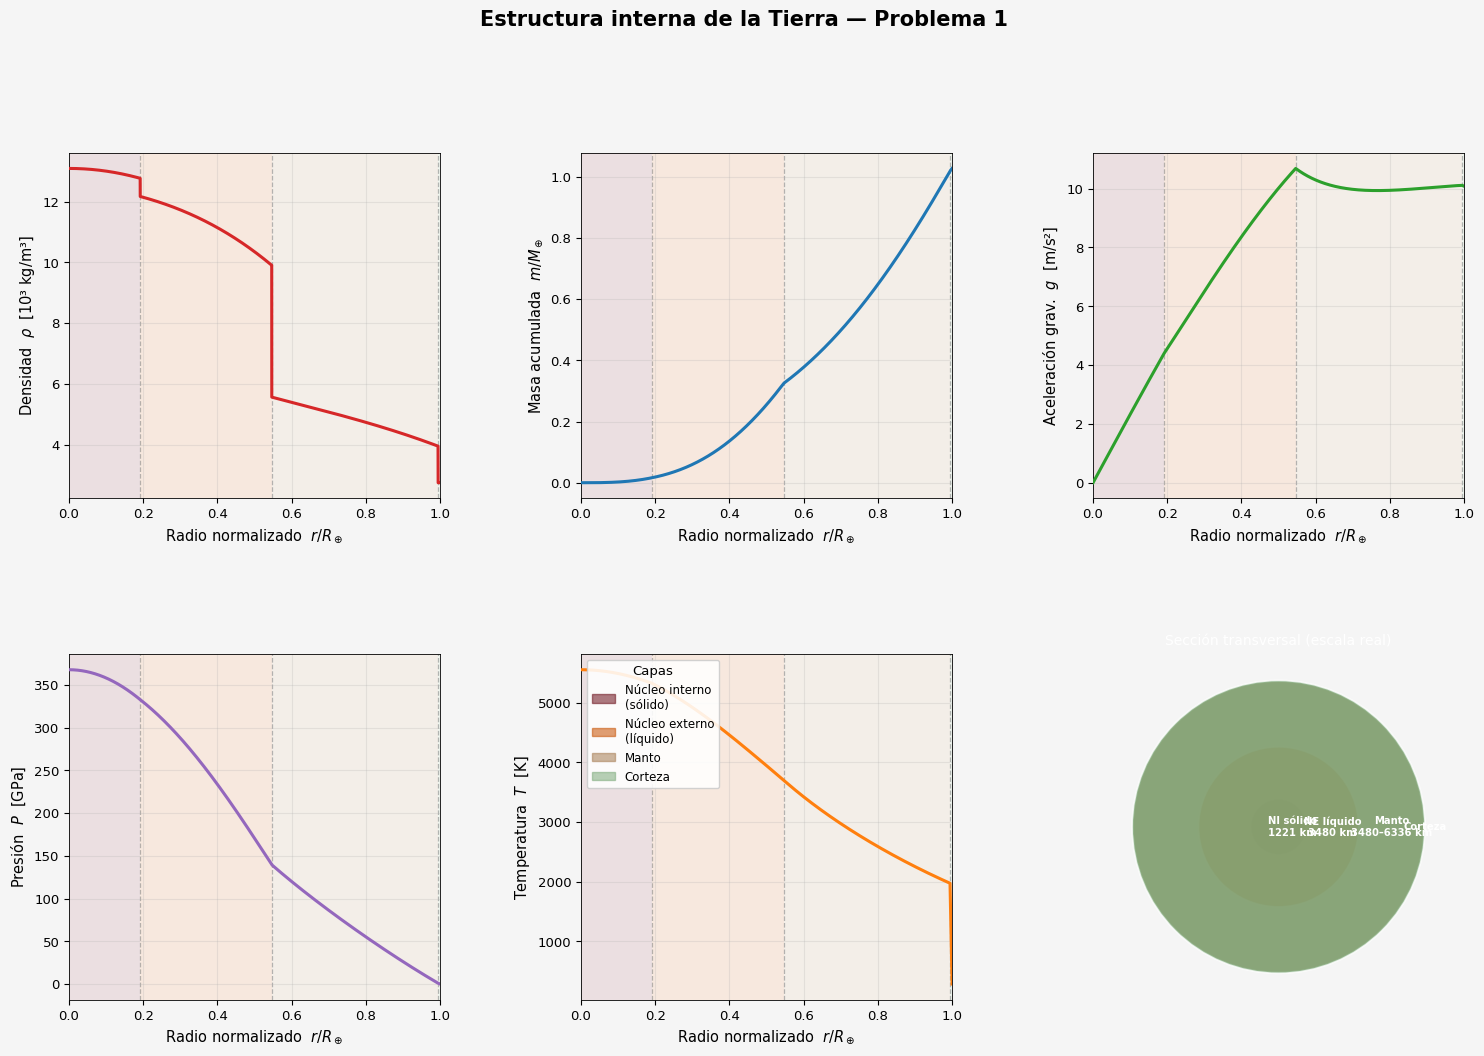

In [ ]:
# ── Definición de colores y etiquetas por capa ───────────────────
layer_colors = ['#6b0f1a', '#c85000', '#a67c52', '#7daa7a']
layer_labels = ['Núcleo interno\n(sólido)', 'Núcleo externo\n(líquido)',
                'Manto', 'Corteza']
layer_bounds = [0, r_IC, r_CMB, r_Moho, R_E]

def shade_layers(ax):
    """Añade bandas de color de fondo para cada capa."""
    for k in range(4):
        ax.axvspan(layer_bounds[k]/R_E, layer_bounds[k+1]/R_E,
                   color=layer_colors[k], alpha=0.13, lw=0, zorder=0)
    for bound in [r_IC, r_CMB, r_Moho]:
        ax.axvline(bound/R_E, color='gray', lw=0.9, ls='--', alpha=0.55, zorder=1)

r_norm = r / R_E   # radio normalizado

# ── Crear la figura con 6 paneles ──────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#f5f5f5')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
axes = [fig.add_subplot(gs[i//3, i%3]) for i in range(5)]

profile_specs = [
    (rho/1e3,   r'Densidad  $\rho$  [10³ kg/m³]',    'tab:red',    'densidad'),
    (m/M_E,     r'Masa acumulada  $m/M_\oplus$',      'tab:blue',   'masa'),
    (g,         r'Aceleración grav.  $g$  [m/s²]',     'tab:green',  'gravedad'),
    (P/1e9,     r'Presión  $P$  [GPa]',                'tab:purple', 'presión'),
    (T,         r'Temperatura  $T$  [K]',              'tab:orange', 'temperatura'),
]

for ax, (ydata, ylabel, color, _) in zip(axes, profile_specs):
    shade_layers(ax)
    ax.plot(r_norm, ydata, color=color, lw=2.2, zorder=5)
    ax.set_xlabel(r'Radio normalizado  $r/R_\oplus$', fontsize=10.5)
    ax.set_ylabel(ylabel, fontsize=10.5)
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.25, zorder=0)
    ax.tick_params(labelsize=9.5)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)

# ── Leyenda de capas sobre el panel de temperatura ───────────────
legend_patches = [mpatches.Patch(color=layer_colors[k], alpha=0.55,
                                  label=layer_labels[k]) for k in range(4)]
axes[4].legend(handles=legend_patches, loc='upper left',
               fontsize=8.5, title='Capas', title_fontsize=9.5,
               framealpha=0.88)

# ── Sexto panel: sección transversal esquemática ─────────────────
ax6 = fig.add_subplot(gs[1, 2], aspect='equal')
ax6.set_facecolor('#0d1117')
radii_frac = [r_IC/R_E, r_CMB/R_E, r_Moho/R_E, 1.0]
for k in range(3, -1, -1):
    circ = Circle((0, 0), radii_frac[k], color=layer_colors[k],
                  alpha=0.78, lw=1.2, ec='white', zorder=k+1)
    ax6.add_patch(circ)
# Etiquetas radiales
annot_data = [
    (r_IC/R_E * 0.50,                              'NI sólido\n1221 km'),
    ((r_IC + r_CMB)/(2*R_E),                       'NE líquido\n3480 km'),
    ((r_CMB + r_Moho)/(2*R_E),                     'Manto\n3480–6336 km'),
    ((r_Moho + R_E)/(2*R_E),                       'Corteza'),
]
for xpos, lbl in annot_data:
    ax6.text(xpos, 0, lbl, ha='center', va='center',
             fontsize=7.2, color='white', fontweight='bold', zorder=20)
ax6.set_xlim(-1.18, 1.18)
ax6.set_ylim(-1.18, 1.18)
ax6.set_title('Sección transversal (escala real)', fontsize=10, color='white', pad=6)
ax6.axis('off')

fig.suptitle('Estructura interna de la Tierra — Problema 1',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/tmp/p1_estructura.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


# Problema 2 — Magnetosferas de los Planetas Gigantes

Para calcular el tamaño de las magnetosferas de los planetas, **Grießmeier et al. (2009)** proponen un modelo basado en el equilibrio de presiones entre el viento solar y el campo magnético planetario.

### 1. Modelo de viento solar — Solución transsónica de Parker (1958)

La ecuación de Parker para un viento solar isotérmico con temperatura coronal $T_c$ es:

$$\frac{v^2}{v_c^2} - \ln\frac{v^2}{v_c^2} = 4\ln\frac{r}{r_c} + \frac{4r_c}{r} - 3$$

donde:
- $v_c = \sqrt{k_B T_c/m_p}$ — velocidad sónica en el punto crítico
- $r_c = GM_\odot/(2v_c^2)$ — radio crítico (punto transsónico)

La densidad del viento solar se obtiene de la conservación del flujo de masa:
$$n(r) = n_\text{1UA} \left(\frac{1\text{ UA}}{r}\right)^2 \frac{v_\text{1UA}}{v(r)}$$

La temperatura decae adiabáticamente: $T_\text{sw}(r) = T_\text{1UA}(1\text{ UA}/r)^{4/3}$.

### 2. Distancia de separación de la magnetosfera ($R_s$)

La *standoff distance* se obtiene del equilibrio de presiones en el punto subestelar (Grießmeier et al. 2009, ec. 14):

$$R_s = \left[\frac{\mu_0 f_0^2 \mathcal{M}^2}{8\pi^2\left(m_p n v_\text{eff}^2 + 2nk_B T_\text{sw}\right)}\right]^{1/6}$$

- $\mathcal{M}$ — momento magnético dipolar del planeta [A·m²]
- $f_0 = 1.16$ — factor de forma de la magnetosfera
- $v_\text{eff} = \sqrt{v^2 + v_\text{orbital}^2}$ — velocidad efectiva del viento solar
- El denominador incluye presión dinámica (*ram pressure*) y presión térmica


## 2.1 Implementación del modelo de Parker

Se resuelve numéricamente la ecuación de Parker usando `scipy.optimize.brentq` para obtener la rama transsónica (subsónica para $r < r_c$, supersónica para $r > r_c$).


Velocidad crítica  :  v_c = 111.3 km/s
Radio crítico      :  r_c = 0.0358 UA = 7.7 R_☉


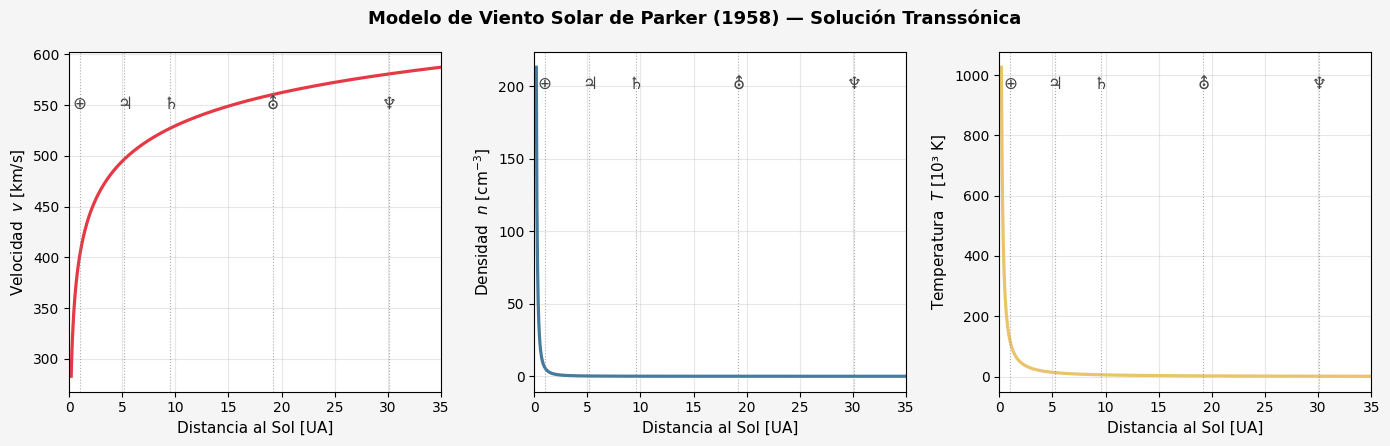


Viento solar en 1 UA  :  v = 401.6 km/s,  n = 6.0 cm⁻³
Viento solar en 5.2 UA:  v = 496.8 km/s,  n = 0.1794 cm⁻³


In [ ]:
# ── Modelo de Parker (1958) ───────────────────────────────────────
T_corona  = 1.5e6   # temperatura coronal isotérmica [K]
v_c = np.sqrt(kB * T_corona / m_p)   # velocidad sónica en el punto crítico [m/s]
r_c = G * M_sun / (2.0 * v_c**2)     # radio crítico [m]

print(f"Velocidad crítica  :  v_c = {v_c/1e3:.1f} km/s")
print(f"Radio crítico      :  r_c = {r_c/AU:.4f} UA = {r_c/R_sun:.1f} R_☉")

def parker_v(r):
    """
    Velocidad del viento solar en la solución transsónica de Parker [m/s].

    Resuelve  u − ln(u) = C  donde  u = (v/v_c)²,  C = 4 ln(r/r_c) + 4(r_c/r) − 3.
    Para r > r_c se usa la rama supersónica (solución física del viento solar).
    """
    x = r / r_c
    if x <= 0:
        return 0.0
    C = 4.0*np.log(x) + 4.0/x - 3.0

    def f_parker(u):
        return u - np.log(u) - C   # = 0 en la solución

    if x <= 1.0:           # subsónico: u ∈ (0, 1)
        u = brentq(f_parker, 1e-14, 1.0 - 1e-12)
    else:                  # supersónico (solución transsónica física): u > 1
        u_hi = max(20.0, 4.0*np.log(x) + 10.0)
        while f_parker(u_hi) < 0:
            u_hi *= 2.0
        u = brentq(f_parker, 1.0 + 1e-12, u_hi)
    return v_c * np.sqrt(u)

parker_v_vec = np.vectorize(parker_v)

# ── Condiciones de referencia en 1 UA (viento solar típico) ──────
v_1AU    = parker_v(AU)    # velocidad en 1 UA [m/s]
n_1AU    = 6.0e6           # densidad numérica en 1 UA [m⁻³] (≈ 6 cm⁻³)
T_sw_1AU = 1.2e5           # temperatura del viento solar en 1 UA [K]

def sw_density(r):
    """Densidad numérica del viento solar por conservación del flujo de masa [m⁻³]."""
    return n_1AU * (AU/r)**2 * (v_1AU / parker_v(r))

def sw_temperature(r):
    """Temperatura del viento solar: enfriamiento adiabático T ∝ r^(−4/3) [K]."""
    return T_sw_1AU * (AU/r)**(4.0/3.0)

# ── Graficar el perfil del viento solar ──────────────────────────
r_sw     = np.linspace(0.2*AU, 35.0*AU, 600)
v_sw_arr = parker_v_vec(r_sw)
n_sw_arr = np.array([sw_density(ri) for ri in r_sw])
T_sw_arr = np.array([sw_temperature(ri) for ri in r_sw])

fig_sw, axs_sw = plt.subplots(1, 3, figsize=(14, 4.5))
fig_sw.patch.set_facecolor('#f5f5f5')

sw_panels = [
    (v_sw_arr/1e3,     'Velocidad  $v$ [km/s]',          '#e63946'),
    (n_sw_arr/1e6,     'Densidad  $n$ [cm$^{-3}$]',      '#457b9d'),
    (T_sw_arr/1e3,     'Temperatura  $T$ [10³ K]',        '#e9c46a'),
]
# Posiciones de los planetas (distancia en UA y símbolo)
planet_marks = [(1.00, '⊕'), (5.20, '♃'), (9.54, '♄'), (19.2, '⛢'), (30.1, '♆')]

for ax, (ydata, ylabel, col) in zip(axs_sw, sw_panels):
    ax.plot(r_sw/AU, ydata, color=col, lw=2.3)
    ax.set_xlabel('Distancia al Sol [UA]', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(0, 35)
    ax.grid(True, alpha=0.3)
    ymax = ydata.max()
    for d, sym in planet_marks:
        ax.axvline(d, color='gray', lw=0.8, ls=':', alpha=0.65)
        ax.text(d, ymax*0.93, sym, ha='center', fontsize=12, color='#444')

fig_sw.suptitle('Modelo de Viento Solar de Parker (1958) — Solución Transsónica',
                fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nViento solar en 1 UA  :  v = {v_1AU/1e3:.1f} km/s,  n = {n_1AU/1e6:.1f} cm⁻³")
print(f"Viento solar en 5.2 UA:  v = {parker_v(5.2*AU)/1e3:.1f} km/s,  "
      f"n = {sw_density(5.2*AU)/1e6:.4f} cm⁻³")


\
## 2.2 Cálculo de la distancia de separación

Se aplica la ecuación de equilibrio (Grießmeier et al. 2009) con los momentos magnéticos de cada planeta. Los valores proceden de Russell (1993) y Connerney et al. (1991).

| Planeta   | $d$ [UA] | $\mathcal{M}$ [A·m²] | $R_p$ [km] |
|-----------|----------|----------------------|------------|
| Tierra    | 1.00     | $8.0\times10^{22}$   | 6 371      |
| Júpiter   | 5.20     | $1.56\times10^{27}$  | 71 490     |
| Saturno   | 9.54     | $4.60\times10^{25}$  | 60 270     |
| Urano     | 19.19    | $3.00\times10^{24}$  | 25 360     |
| Neptuno   | 30.07    | $2.20\times10^{24}$  | 24 630     |


In [ ]:
f0 = 1.16   # factor de forma de la magnetosfera (Grießmeier et al. 2009)

def standoff_distance(r_orb, M_mag):
    """
    Calcula la distancia de separación Rs de la magnetosfera.

    Parámetros
    ----------
    r_orb : float   Distancia orbital [m]
    M_mag : float   Momento magnético dipolar [A·m²]

    Devuelve
    --------
    Rs [m], v_sw [m/s], n_sw [m⁻³], T_sw [K], P_ram [Pa], P_thermal [Pa]
    """
    v      = parker_v(r_orb)              # velocidad viento solar
    n      = sw_density(r_orb)            # densidad viento solar
    T_sw   = sw_temperature(r_orb)        # temperatura viento solar
    v_orb  = np.sqrt(G * M_sun / r_orb)  # velocidad orbital
    v_eff  = np.sqrt(v**2 + v_orb**2)    # velocidad efectiva (viento + orbital)

    P_ram     = m_p * n * v_eff**2       # presión dinámica (ram pressure)
    P_thermal = 2.0 * n * kB * T_sw     # presión térmica (e⁻ + H⁺)
    P_total   = P_ram + P_thermal

    Rs = (mu0 * f0**2 * M_mag**2 / (8.0 * np.pi**2 * P_total))**(1.0/6.0)
    return Rs, v, n, T_sw, P_ram, P_thermal

# ── Datos de los planetas gigantes + Tierra (referencia) ─────────
planetas = [
    {'nombre': 'Tierra',  'd_AU': 1.000, 'M_mag': 8.00e22, 'R_p': 6.371e6, 'color': '#2980b9'},
    {'nombre': 'Júpiter', 'd_AU': 5.203, 'M_mag': 1.56e27, 'R_p': 7.149e7, 'color': '#e87722'},
    {'nombre': 'Saturno', 'd_AU': 9.537, 'M_mag': 4.60e25, 'R_p': 6.027e7, 'color': '#c19a6b'},
    {'nombre': 'Urano',   'd_AU': 19.19, 'M_mag': 3.00e24, 'R_p': 2.536e7, 'color': '#54c1e0'},
    {'nombre': 'Neptuno', 'd_AU': 30.07, 'M_mag': 2.20e24, 'R_p': 2.463e7, 'color': '#3c5794'},
]

resultados = []
print(f"{'Planeta':<10} {'d (UA)':>8} {'v (km/s)':>10} {'n (cm⁻³)':>10} "
      f"{'P_ram (nPa)':>12} {'Rs (Rp)':>9} {'Rs (103 km)':>12}")
print('─'*78)
for p in planetas:
    r_orb = p['d_AU'] * AU
    Rs, v, n, T_sw, P_ram, P_th = standoff_distance(r_orb, p['M_mag'])
    resultados.append({**p, 'Rs': Rs, 'v_sw': v, 'n_sw': n, 'P_ram': P_ram})
    print(f"{p['nombre']:<10} {p['d_AU']:>8.3f} {v/1e3:>10.1f} {n/1e6:>10.3f} "
          f"{P_ram*1e9:>12.4f} {Rs/p['R_p']:>9.1f} {Rs/1e6:>12.1f}")


Planeta      d (UA)   v (km/s)   n (cm⁻³)  P_ram (nPa)   Rs (Rp)  Rs (103 km)
──────────────────────────────────────────────────────────────────────────────
Tierra        1.000      401.6      6.000       1.6279      10.4         66.1
Júpiter       5.203      496.8      0.179       0.0740      41.7       2982.2
Saturno       9.537      527.4      0.050       0.0234      18.5       1116.5
Urano        19.190      560.5      0.012       0.0061      22.1        561.7
Neptuno      30.070      580.8      0.005       0.0026      23.7        584.9


## 2.3 Visualización de las magnetosferas

Se presentan cuatro paneles: **(a)** distancia de separación en radios planetarios, **(b)** distancia en kilómetros, **(c)** diagrama esquemático comparativo y **(d)** ley de escala $R_s \propto \mathcal{M}^{1/3}$.


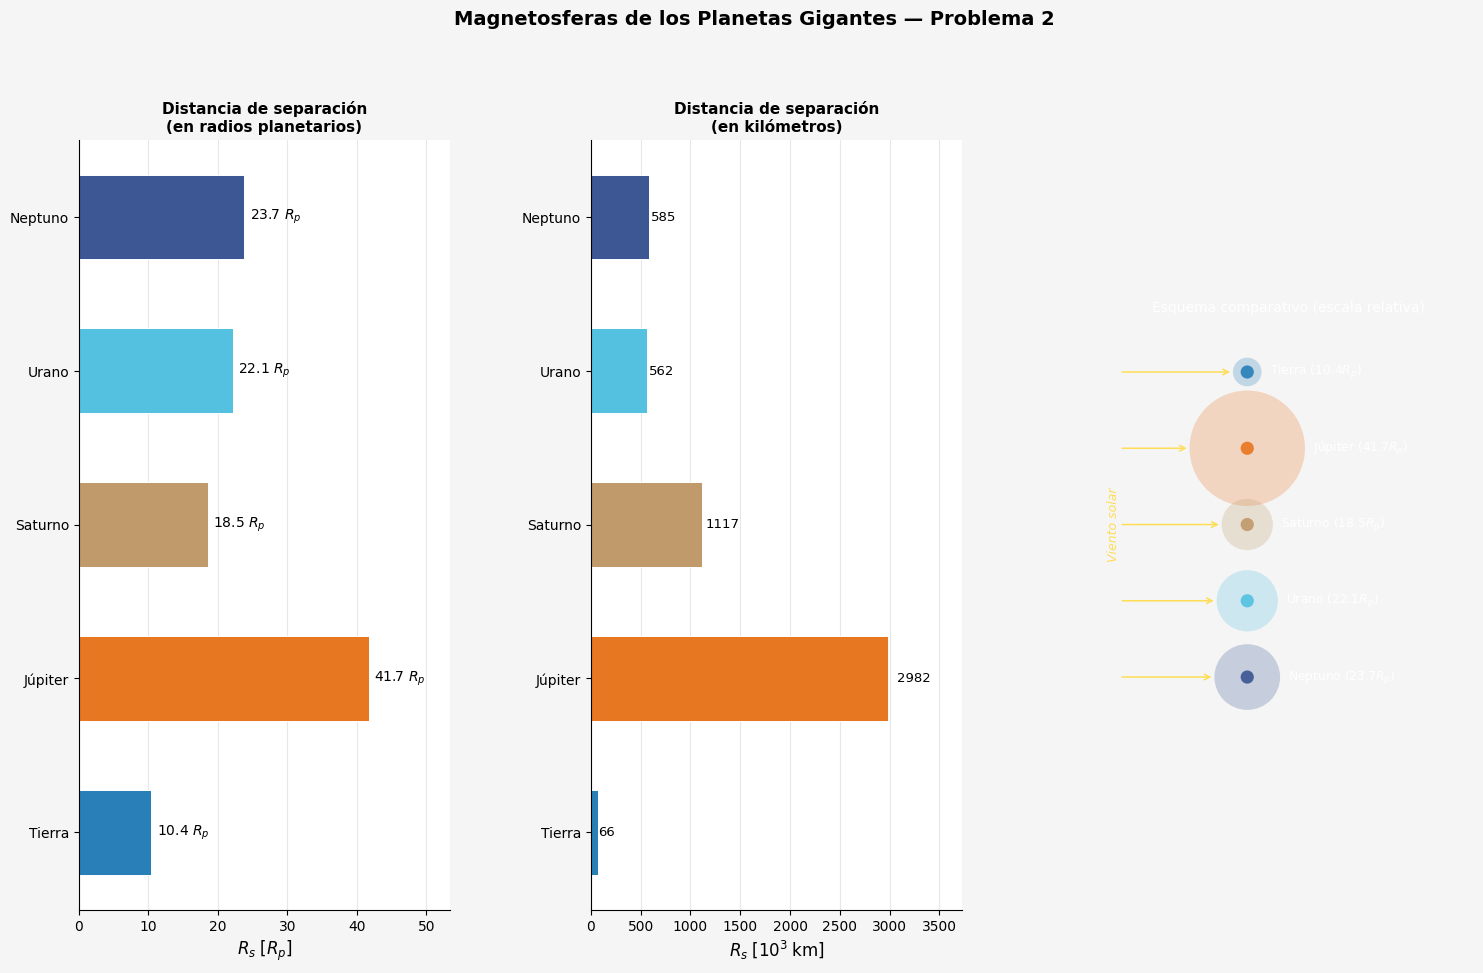

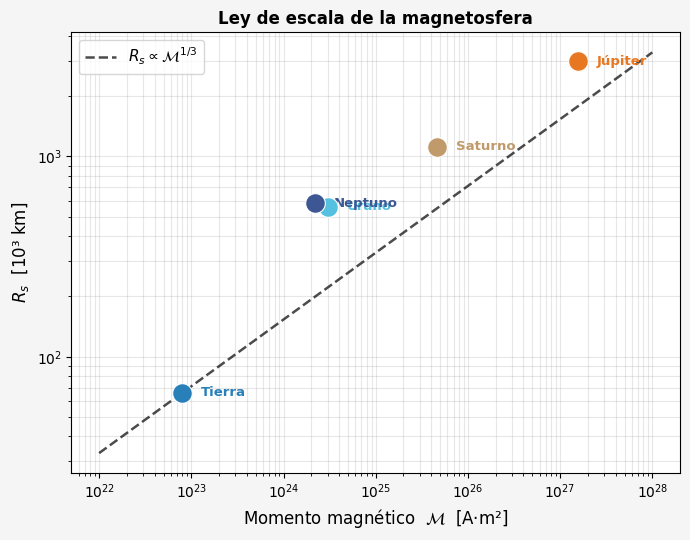

In [ ]:
nombres  = [p['nombre']   for p in resultados]
Rs_Rp    = [p['Rs']/p['R_p'] for p in resultados]
Rs_km    = [p['Rs']/1e6    for p in resultados]
M_mags   = [p['M_mag']    for p in resultados]
colors_p = [p['color']    for p in resultados]

# ── Figura principal: 4 paneles ───────────────────────────────────
fig2 = plt.figure(figsize=(18, 10))
fig2.patch.set_facecolor('#f5f5f5')
gs2 = GridSpec(1, 3, figure=fig2, wspace=0.38)
ax_a = fig2.add_subplot(gs2[0, 0])
ax_b = fig2.add_subplot(gs2[0, 1])
ax_c = fig2.add_subplot(gs2[0, 2], aspect='equal')

# ── Panel A: Rs en radios planetarios ────────────────────────────
bars_a = ax_a.barh(nombres, Rs_Rp, color=colors_p, edgecolor='white',
                   linewidth=0.7, height=0.55)
for bar, val in zip(bars_a, Rs_Rp):
    ax_a.text(val + 0.8, bar.get_y() + bar.get_height()/2,
              f'{val:.1f} $R_p$', va='center', fontsize=10)
ax_a.set_xlabel(r'$R_s\;[R_p]$', fontsize=12)
ax_a.set_title('Distancia de separación\n(en radios planetarios)', fontsize=11, fontweight='bold')
ax_a.set_xlim(0, max(Rs_Rp)*1.28)
ax_a.grid(True, axis='x', alpha=0.3); ax_a.set_axisbelow(True)
ax_a.spines[['top','right']].set_visible(False)

# ── Panel B: Rs en 10³ km ─────────────────────────────────────────
bars_b = ax_b.barh(nombres, Rs_km, color=colors_p, edgecolor='white',
                   linewidth=0.7, height=0.55)
for bar, val in zip(bars_b, Rs_km):
    ax_b.text(val*1.03, bar.get_y() + bar.get_height()/2,
              f'{val:.0f}', va='center', fontsize=9.5)
ax_b.set_xlabel(r'$R_s\;[10^3\;\mathrm{km}]$', fontsize=12)
ax_b.set_title('Distancia de separación\n(en kilómetros)', fontsize=11, fontweight='bold')
ax_b.set_xlim(0, max(Rs_km)*1.25)
ax_b.grid(True, axis='x', alpha=0.3); ax_b.set_axisbelow(True)
ax_b.spines[['top','right']].set_visible(False)

# ── Panel C: esquema comparativo de magnetosferas ────────────────
ax_c.set_facecolor('#0a0a2a')
ax_c.set_xlim(0.1, 1.0)
ax_c.set_ylim(0.0, 1.0)
positions_y = np.linspace(0.87, 0.13, 5)
scale = 0.14 / max(Rs_Rp)   # normalización para que Júpiter ocupe ~14% del eje
for p, Rp_n, y0 in zip(resultados, Rs_Rp, positions_y):
    r_mag = Rp_n * scale
    r_pla = 0.016
    # magnetosfera
    mag_patch = Circle((0.45, y0), r_mag, color=p['color'], alpha=0.25, lw=0)
    ax_c.add_patch(mag_patch)
    # planeta
    pla_patch = Circle((0.45, y0), r_pla, color=p['color'], alpha=0.92, lw=0)
    ax_c.add_patch(pla_patch)
    # etiqueta
    ax_c.text(0.45 + r_mag + 0.02, y0, f"{p['nombre']} ({Rp_n:.1f}$R_p$)",
              va='center', fontsize=8.8, color='white')
    # flecha viento solar
    ax_c.annotate('', xy=(0.45 - r_mag, y0), xytext=(0.14, y0),
                  arrowprops=dict(arrowstyle='->', color='#ffdd55', lw=1.1))
ax_c.text(0.11, 0.5, 'Viento solar', rotation=90, va='center',
          fontsize=9, color='#ffdd55', style='italic')
ax_c.set_title('Esquema comparativo (escala relativa)', fontsize=10,
               color='white', pad=5)
ax_c.axis('off')

fig2.suptitle('Magnetosferas de los Planetas Gigantes — Problema 2',
              fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/tmp/p2_magnetosferas.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()

# ── Figura secundaria: ley de escala Rs ∝ M^{1/3} ────────────────
fig3, ax_sc = plt.subplots(figsize=(7, 5.5))
fig3.patch.set_facecolor('#f5f5f5')
for p, Rp_n, col in zip(resultados, Rs_Rp, colors_p):
    ax_sc.scatter(p['M_mag'], p['Rs']/1e6, s=200, color=col, zorder=5,
                  edgecolors='white', linewidth=0.8)
    ax_sc.text(p['M_mag']*1.6, p['Rs']/1e6, p['nombre'],
               va='center', fontsize=9.5, color=col, fontweight='bold')
# Ley de escala Rs ∝ M^{1/3}
M_fit = np.logspace(22, 28, 200)
Rs_E_ref = resultados[0]['Rs']
M_E_ref  = resultados[0]['M_mag']
Rs_fit = Rs_E_ref/1e6 * (M_fit/M_E_ref)**(1.0/3.0)
ax_sc.loglog(M_fit, Rs_fit, 'k--', lw=1.8, alpha=0.7,
             label=r'$R_s \propto \mathcal{M}^{1/3}$')
ax_sc.legend(fontsize=11)
ax_sc.set_xlabel(r'Momento magnético  $\mathcal{M}$  [A·m²]', fontsize=12)
ax_sc.set_ylabel(r'$R_s$  [10³ km]', fontsize=12)
ax_sc.set_title(r'Ley de escala de la magnetosfera', fontsize=12, fontweight='bold')
ax_sc.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()
